# Evaluation of LP (synthetic dataset)
# 1. install required packages

In [ ]:
import numpy as np
import pandas as pd
import random
import time
from gurobipy import *

# 2. model problem setting: Gurobi
- MCLP problem

In [2]:
def gurobi_solver_MCLP(users, facilities, demand, PN, A):
    # Problem datas
    N = len(users)
    M = len(facilities)

    model = Model('MCLP')
    model.setParam('OutputFlag', False)
    model.setParam('MIPFocus', 2)
    # Add variables
    client_var = {}
    serv_var = {}

    # Add Client Decision Variables and Service Decision Variables
    for j in range(N):
        client_var[j] = model.addVar(vtype="B", name="y(%s)"%j)
    for i in range(M):
        serv_var[i] = model.addVar(vtype="B", name="x(%s)"%i)
    # Update Model Variables
    model.update()
    #     Set Objective Function
    model.setObjective(quicksum(demand[j]*client_var[j] for j in range(N)), GRB.MAXIMIZE)
    #     Add Constraints
    # Add Coverage Constraints
    for j in range(N):
        model.addConstr(quicksum (A[i,j]*serv_var[i] for i in range(M)) - client_var[j] >= 0,
                        'Coverage_Constraint_%d' % j)

    # Add Facility Constraint
    model.addConstr(quicksum(serv_var[i] for i in range(M)) == PN,
                "Facility_Constraint")

    model.optimize()

    # return a stardard result list
    x_result = []
    for i in range(M):
        x_result.append(serv_var[i].X)
    y_result = []
    for j in range(N):
        y_result.append(client_var[j].X)
    obj = model.ObjVal
    return x_result, y_result, obj

# 3. LP performance evaluation
### assessing performance and computation time based on changes in total supply points anad candidate locations

- total demand point: 4000

- **m: number of total supply candidate points**

- **p: number of final selected supply points**


### model run
- total model runs: `len(m_range)` × `len(p_range)` = 180 runs
- when m is 3000: Time (or objective value) varies with p values → line 1 (30 data points)
- when m is 2500: Time (or objective value) varies with p values → line 2 (30 data points)
- ...
- when m is 500: Time (or objective value) varies with p values → line 6 (30 data points)

In [3]:
m_range = list(range(3000, 0, -500))
p_range = list(range(300, 0, -10))

In [4]:
n_users = 4000
n_facilities = m_range[-1]
users = np.array([(random.random(), random.random()) for _ in range(n_users)])
demand = np.random.randint(1, 2, size=n_users)
radius = 0.15

In [5]:
results = pd.DataFrame(columns=['m', 'p', 'objective', 'time'])
solutions_dict = {}

In [ ]:
for m in m_range:
    # Regenerate Facilities (on each change of M value)
    facilities = np.array([(random.random(), random.random()) for _ in range(m)])
    
    # Recalculate Coverage Matrix A (on each change of M value)
    A = np.sum((facilities[:, np.newaxis, :] - users[np.newaxis, :, :]) ** 2, axis=-1) ** 0.5
    mask = A <= radius
    A = mask.astype(int)
    
    for p in p_range:
        if p > m:  #skip if p > m
            print(f"Skipping p={p} (p > m={m})")
            continue
            
        start_time = time.time()
        try:
            x_result, y_result, obj = gurobi_solver_MCLP(users, facilities, demand, p, A)
            print(f"m_range is {m} & p_range is {p} \n and The avg objective of MCLP samples is: {obj}")
            elapsed = time.time() - start_time
            
            # save selected values
            selected_facilities = [i for i, x in enumerate(x_result) if x == 1.0]
            solutions_dict[(m, p)] = selected_facilities

            # save results
            results = results.append({
                'm': m,
                'p': p,
                'objective': obj,
                'time': elapsed
            }, ignore_index=True)
            
            print(f"m={m:<4} | p={p:<3} | obj={obj:<7.1f} | time={elapsed:.2f}s")
            
        except Exception as e:
            print(f"Error at m={m}, p={p}: {str(e)}")

Set parameter Username
Set parameter LicenseID to value 2646023
Academic license - for non-commercial use only - expires 2026-04-01
m_range is 3000 & p_range is 300 
 and The avg objective of MCLP samples is: 4000.0
m=3000 | p=300 | obj=4000.0  | time=176.90s
m_range is 3000 & p_range is 290 
 and The avg objective of MCLP samples is: 4000.0
m=3000 | p=290 | obj=4000.0  | time=172.62s
m_range is 3000 & p_range is 280 
 and The avg objective of MCLP samples is: 4000.0
m=3000 | p=280 | obj=4000.0  | time=170.99s
m_range is 3000 & p_range is 270 
 and The avg objective of MCLP samples is: 4000.0
m=3000 | p=270 | obj=4000.0  | time=177.52s
m_range is 3000 & p_range is 260 
 and The avg objective of MCLP samples is: 4000.0
m=3000 | p=260 | obj=4000.0  | time=190.74s
m_range is 3000 & p_range is 250 
 and The avg objective of MCLP samples is: 4000.0
m=3000 | p=250 | obj=4000.0  | time=169.80s
m_range is 3000 & p_range is 240 
 and The avg objective of MCLP samples is: 4000.0
m=3000 | p=240 |

In [20]:
results.to_csv('gurobi_performance.csv', index=False)

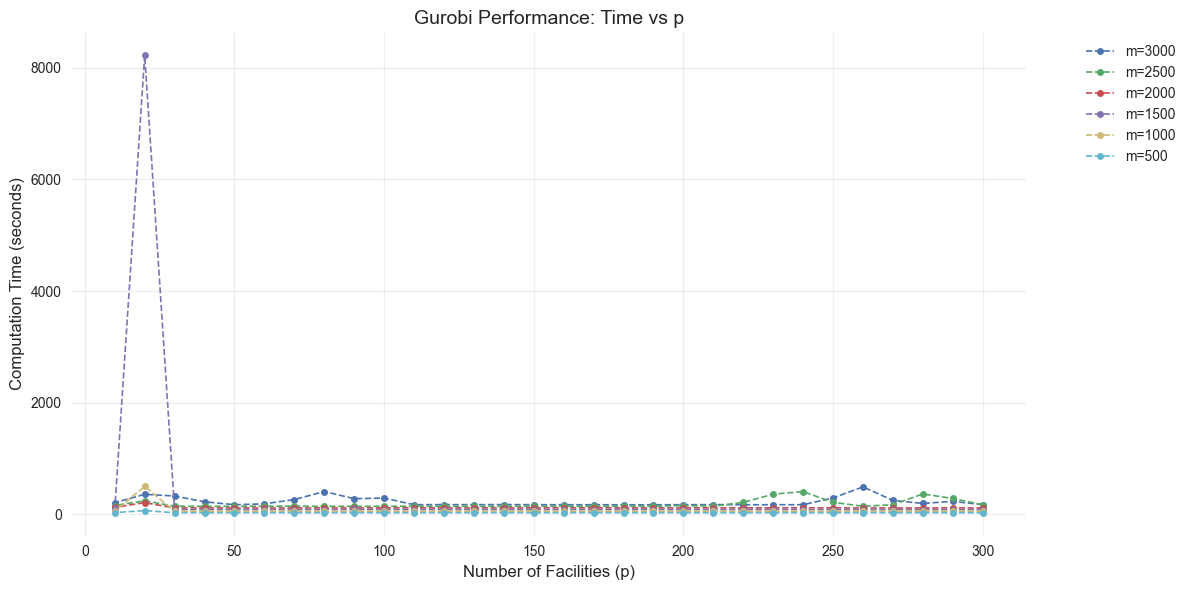

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn')
sns.set_style('white')

# plot for time
plt.figure(figsize=(12, 6))
for m_val in m_range:
    mask = results['m'] == m_val
    plt.plot(results[mask]['p'], results[mask]['time'], 
             marker='o', linestyle='--', linewidth=1.2, markersize=5, 
             label=f'm={m_val}')
plt.title('Gurobi Performance: Time vs p', fontsize=14)
plt.xlabel('Number of Facilities (p)', fontsize=12)
plt.ylabel('Computation Time (seconds)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
results_outlier = results.loc[results['m']!=1500]

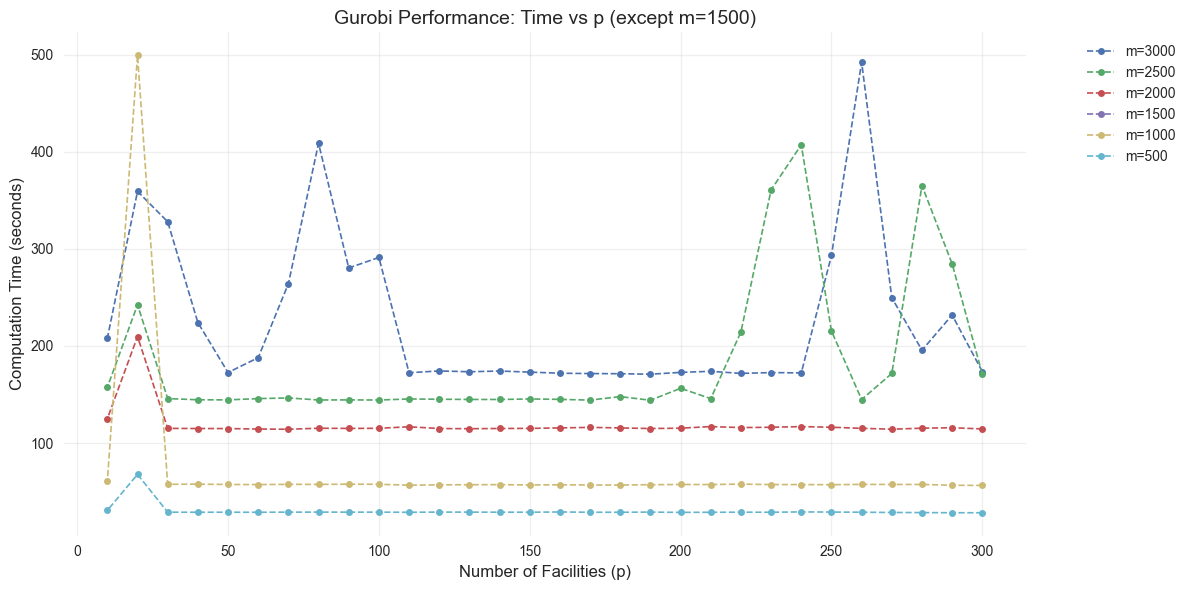

In [ ]:
# plot for time (except m=1500)
plt.figure(figsize=(12, 6))
for m_val in m_range:
    mask = results_outlier['m'] == m_val
    plt.plot(results_outlier[mask]['p'], results_outlier[mask]['time'], 
             marker='o', linestyle='--', linewidth=1.2, markersize=5, 
             label=f'm={m_val}')
plt.title('Gurobi Performance: Time vs p (except m=1500)', fontsize=14)
plt.xlabel('Number of Facilities (p)', fontsize=12)
plt.ylabel('Computation Time (seconds)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

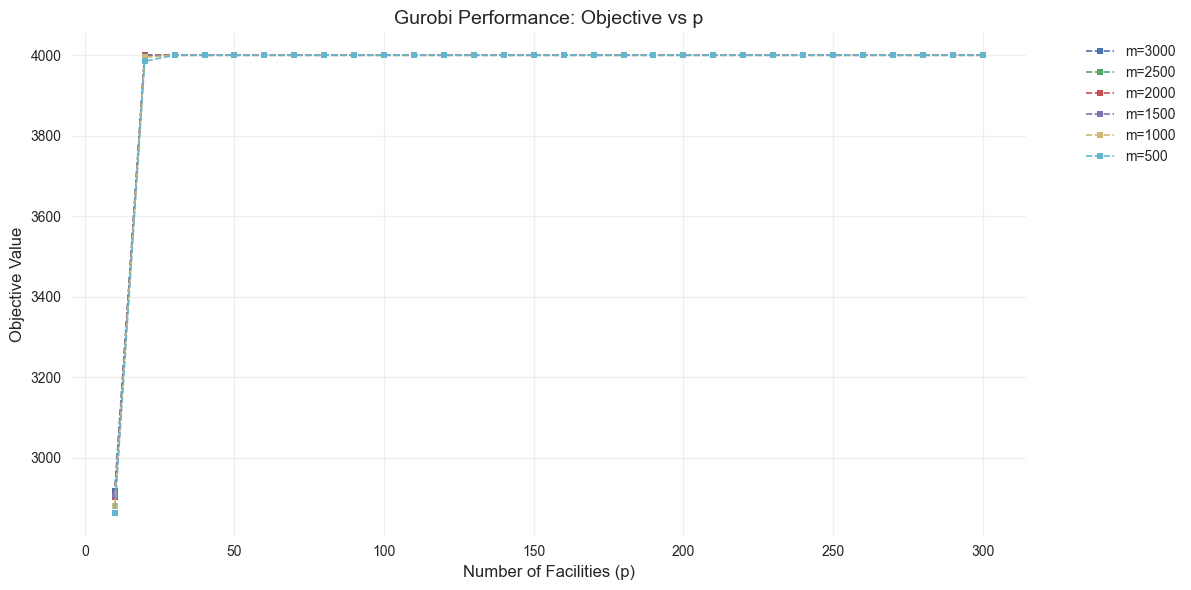

In [ ]:
# plot for obj.
plt.figure(figsize=(12, 6))
for m_val in m_range:
    mask = results['m'] == m_val
    plt.plot(results[mask]['p'], results[mask]['objective'], 
             marker='s', linestyle='--', linewidth=1.2, markersize=5, 
             label=f'm={m_val}')
plt.title('Gurobi Performance: Objective vs p', fontsize=14)
plt.xlabel('Number of Facilities (p)', fontsize=12)
plt.ylabel('Objective Value', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. LP performance evaluation: small range of m & p

In [76]:
m_range = list(range(500, 0, -25))
p_range = list(range(300, 0, -10))

In [78]:
n_users = 4000
n_facilities = m_range[-1]
users = np.array([(random.random(), random.random()) for _ in range(n_users)])
demand = np.random.randint(1, 2, size=n_users)
radius = 0.15

In [81]:
results_small_random = pd.DataFrame(columns=['m', 'p', 'objective', 'time'])
solutions_dict = {}

In [ ]:
for m in m_range:
    # Regenerate Facilities (on each change of M value)
    facilities = np.array([(random.random(), random.random()) for _ in range(m)])
    
    # Recalculate Coverage Matrix A (on each change of M value)
    A = np.sum((facilities[:, np.newaxis, :] - users[np.newaxis, :, :]) ** 2, axis=-1) ** 0.5
    mask = A <= radius
    A = mask.astype(int)
    
    for p in p_range:
        if p > m:  #skip if p > m
            print(f"Skipping p={p} (p > m={m})")
            continue
            
        start_time = time.time()
        try:
            x_result, y_result, obj = gurobi_solver_MCLP(users, facilities, demand, p, A)
            elapsed = time.time() - start_time

            # save results
            results_small_random = results_small_random.append({
                'm': m,
                'p': p,
                'objective': obj,
                'time': elapsed
            }, ignore_index=True)
            
            print(f"m={m:<4} | p={p:<3} | obj={obj:<7.1f} | time={elapsed:.2f}s")
            
        except Exception as e:
            print(f"Error at m={m}, p={p}: {str(e)}")

m=500  | p=300 | obj=4000.0  | time=28.78s
m=500  | p=290 | obj=4000.0  | time=77.74s
m=500  | p=280 | obj=4000.0  | time=80.79s
m=500  | p=270 | obj=4000.0  | time=80.48s
m=500  | p=260 | obj=4000.0  | time=79.95s
m=500  | p=250 | obj=4000.0  | time=79.66s
m=500  | p=240 | obj=4000.0  | time=79.48s
m=500  | p=230 | obj=4000.0  | time=79.70s
m=500  | p=220 | obj=4000.0  | time=81.14s
m=500  | p=210 | obj=4000.0  | time=80.22s
m=500  | p=200 | obj=4000.0  | time=41.02s
m=500  | p=190 | obj=4000.0  | time=35.06s
m=500  | p=180 | obj=4000.0  | time=28.56s
m=500  | p=170 | obj=4000.0  | time=28.89s
m=500  | p=160 | obj=4000.0  | time=34.25s
m=500  | p=150 | obj=4000.0  | time=29.01s
m=500  | p=140 | obj=4000.0  | time=28.87s
m=500  | p=130 | obj=4000.0  | time=43.76s
m=500  | p=120 | obj=4000.0  | time=28.89s
m=500  | p=110 | obj=4000.0  | time=28.90s
m=500  | p=100 | obj=4000.0  | time=34.61s
m=500  | p=90  | obj=4000.0  | time=28.54s
m=500  | p=80  | obj=4000.0  | time=40.15s
m=500  | p=

In [83]:
results_small_random.to_csv('small_gurobi_performance.csv')

In [84]:
results_small_random

,m,p,objective,time
0,500.0,300.0,4000.0,28.784475
1,500.0,290.0,4000.0,77.736400
2,500.0,280.0,4000.0,80.788727
3,500.0,270.0,4000.0,80.481386
4,500.0,260.0,4000.0,79.954328
...,...,...,...,...
427,50.0,30.0,3817.0,3.083724
428,50.0,20.0,3663.0,3.014647
429,50.0,10.0,2600.0,3.014859
430,25.0,20.0,3069.0,1.582649


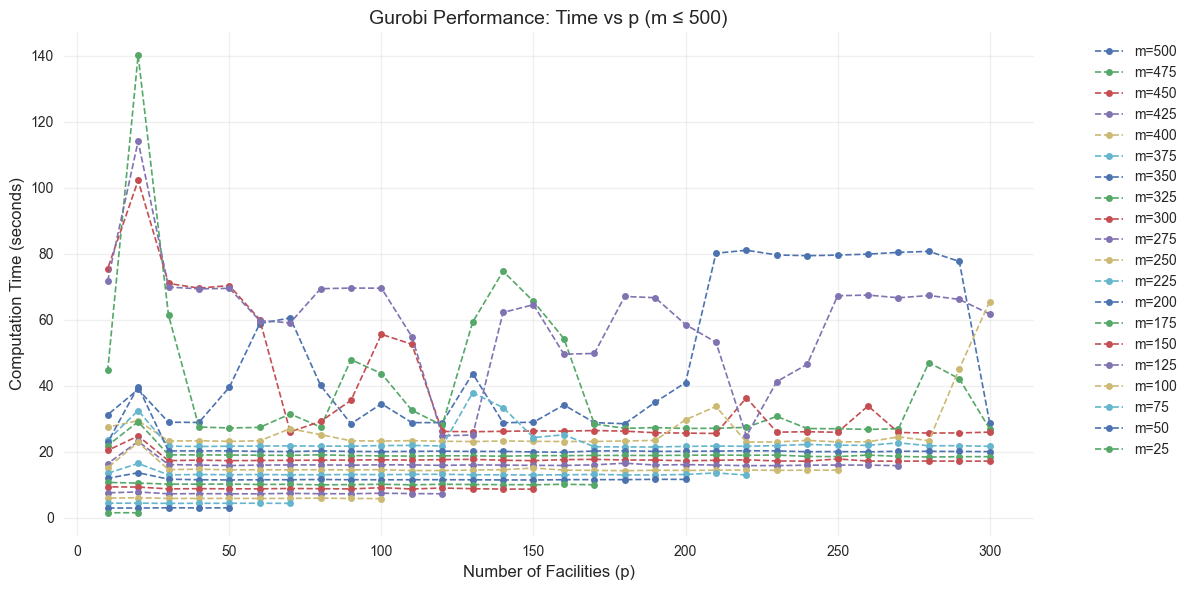

In [ ]:
# plot for time
plt.figure(figsize=(12, 6))
for m_val in m_range:
    mask = results_small_random['m'] == m_val
    plt.plot(results_small_random[mask]['p'], results_small_random[mask]['time'], 
             marker='o', linestyle='--', linewidth=1.2, markersize=5, 
             label=f'm={m_val}')
plt.title('Gurobi Performance: Time vs p (m ≤ 500)', fontsize=14)
plt.xlabel('Number of Facilities (p)', fontsize=12)
plt.ylabel('Computation Time (seconds)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

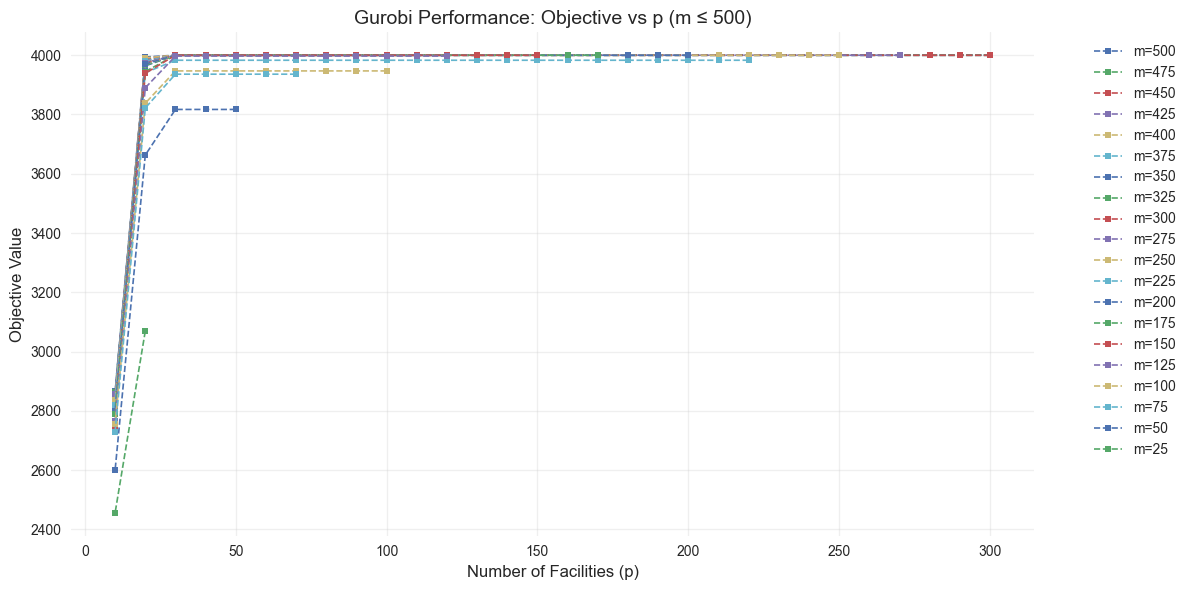

In [ ]:
# plot for obj.
plt.figure(figsize=(12, 6))
for m_val in m_range:
    mask = results_small_random['m'] == m_val
    plt.plot(results_small_random[mask]['p'], results_small_random[mask]['objective'], 
             marker='s', linestyle='--', linewidth=1.2, markersize=5, 
             label=f'm={m_val}')
plt.title('Gurobi Performance: Objective vs p (m ≤ 500)', fontsize=14)
plt.xlabel('Number of Facilities (p)', fontsize=12)
plt.ylabel('Objective Value', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. calculate coefficient of variation

In [89]:
var_by_m = results_small_random.groupby('m')['time'].agg(
    ['mean', 'var', 'std']
).reset_index()
var_by_m['coeff_of_var'] = var_by_m['std'] / var_by_m['mean']

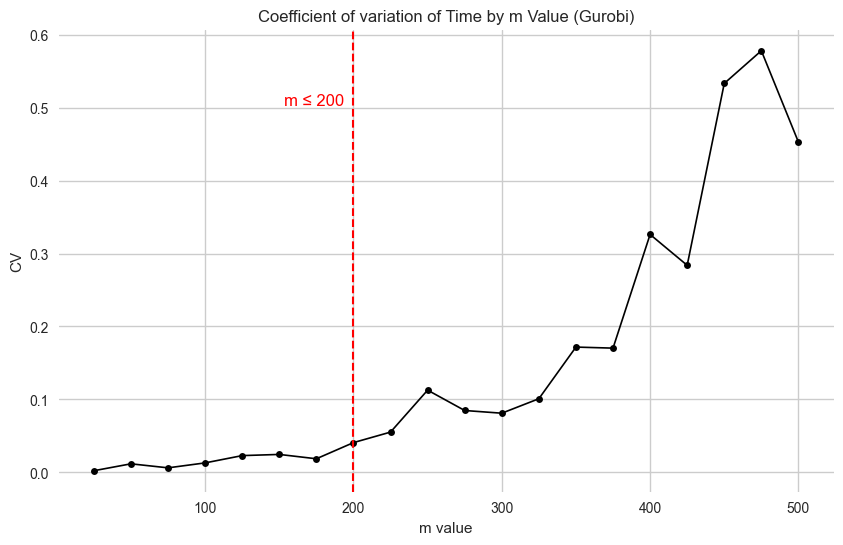

In [ ]:
# plotting
plt.figure(figsize = (10, 6))
plt.plot(var_by_m['m'], var_by_m['coeff_of_var'], marker='o', c='black', linewidth=1.2, markersize=5)
plt.xlabel('m value')
plt.ylabel('CV')
plt.title('Coefficient of variation of Time by m Value (Gurobi)')
plt.grid(True)
#plt.axvline(x=100, color='red', linestyle='--', linewidth=1.5)
plt.axvline(x=200, color='red', linestyle='--', linewidth=1.5)
plt.text(153, var_by_m['coeff_of_var'].max()*0.9, 'm ≤ 200', 
         color='red', fontsize=12, rotation=0, va='top')
plt.show()